<a href="https://colab.research.google.com/github/conluoi123/vnfood_vision/blob/feat_modeling/notebooks/05_llm_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05: LLM Fine-Tuning

Fine-tune Qwen2.5-3B trên `finetune_dataset.jsonl` bằng LoRA + Unsloth, sau đó đánh giá bằng RAGAS.

**Yêu cầu:** Runtime Google Colab với GPU T4 (16GB VRAM)  
**Input:** `VietFood-Project/data/finetune_dataset.jsonl`  
**Output:** `VietFood-Project/checkpoints/llm/` (model đã fine-tune)

> **Lưu ý dataset hiện tại:** File jsonl hiện có **910 mẫu**, gồm 2 loại câu hỏi  
> (allergy: 455, calorie: 455). Chưa có recipe & translation như kế hoạch.  
> Model fine-tune sẽ giỏi 2 task này; các task khác nên dùng base model + RAG prompt.

---
## Cell 0 - Kiểm tra môi trường

In [ ]:
import torch, os

assert torch.cuda.is_available(), "Không tìm thấy GPU. Vào Runtime → Change runtime type → T4 GPU"

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU   : {gpu_name}")
print(f"VRAM  : {vram_gb:.1f} GB")
print(f"PyTorch: {torch.__version__}")

GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.11.0+cu128


---
## Cell 1 - Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH         = '/content/drive/MyDrive/VietFood-Project'
DATASET_PATH       = os.path.join(DRIVE_PATH, 'data', 'finetune', 'finetune_dataset.jsonl')
RAG_KB_PATH        = os.path.join(DRIVE_PATH, 'data', 'base', 'rag_knowledge_base.json')
CHECKPOINT_DIR     = os.path.join(DRIVE_PATH, 'checkpoints', 'llm')
SAVE_DIR           = os.path.join(DRIVE_PATH, 'checkpoints', 'llm', 'finetuned_model')
CHROMADB_DIR       = os.path.join(DRIVE_PATH, 'data', 'chromadb')
REPORT_DIR         = os.path.join(DRIVE_PATH, 'reports', 'llm_eval')

for d in [CHECKPOINT_DIR, SAVE_DIR, CHROMADB_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

assert os.path.exists(DATASET_PATH), f"Không tìm thấy dataset tại: {DATASET_PATH}"
assert os.path.exists(RAG_KB_PATH),  f"Không tìm thấy rag_knowledge_base tại: {RAG_KB_PATH}"
print(f"Dataset         : {DATASET_PATH}")
print(f"RAG Knowledge Base: {RAG_KB_PATH}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")
print(f"ChromaDB dir    : {CHROMADB_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset         : /content/drive/MyDrive/VietFood-Project/data/finetune/finetune_dataset.jsonl
RAG Knowledge Base: /content/drive/MyDrive/VietFood-Project/data/base/rag_knowledge_base.json
Checkpoint dir  : /content/drive/MyDrive/VietFood-Project/checkpoints/llm
ChromaDB dir    : /content/drive/MyDrive/VietFood-Project/data/chromadb


---
## Cell 2 - Cài thư viện

In [ ]:
%%capture
# 1. Core fine-tuning stack
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes

# 2. Xử lý triệt để lỗi Numpy 2.0
!pip install "numpy<2.0" pyarrow datasets --upgrade

# 3. Hệ sinh thái RAG & Đánh giá (Ghim chặt phiên bản ổn định)
!pip install ragas==0.1.7
!pip install langchain==0.1.20
!pip install langchain-core==0.1.52
!pip install langchain-community==0.0.38
!pip install langchain-google-genai==1.0.3
!pip install chromadb sentence-transformers rank-bm25

# 4. Tracking & Visualisation
!pip install wandb matplotlib seaborn plotly

---
## Cell 3 - Khởi tạo W&B

In [ ]:
import wandb

wandb.login()  # Nhập API key lần đầu

# Config sẽ được log đầy đủ sau khi training bắt đầu
WANDB_PROJECT = "viet-food-recognition"
WANDB_RUN_NAME = "llm-finetune-qwen2.5-3b-lora"
print(f"W&B project: {WANDB_PROJECT}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: huynhtrongvien2005 (huynhtrongvien2005-tr-ng-i-h-c-khoa-h-c-t-nhi-n-hqg-hcm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B project: viet-food-recognition


---
## Cell 4 - Load dataset và kiểm tra cấu trúc

In [ ]:
import json
from datasets import Dataset

# Load toàn bộ file jsonl
records = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        records.append(json.loads(line.strip()))

# Kiểm tra phân bố câu hỏi
type_counts = {}
for r in records:
    inst = r['instruction']
    if 'dị ứng' in inst:                              k = 'allergy'
    elif 'calo' in inst:                              k = 'calorie'
    elif 'công thức' in inst or 'cách làm' in inst:  k = 'recipe'
    elif 'tiếng Anh' in inst or 'English' in inst:   k = 'translation'
    else:                                             k = 'other'
    type_counts[k] = type_counts.get(k, 0) + 1

print(f"Tổng số mẫu   : {len(records)}")
print(f"Phân bố loại  : {type_counts}")
print(f"\nVí dụ mẫu #1:")
print(f"   instruction : {records[0]['instruction']}")
print(f"   input (ngắn): {records[0]['input'][:80]}...")
print(f"   output      : {records[0]['output']}")

Tổng số mẫu   : 910
Phân bố loại  : {'allergy': 455, 'calorie': 455}

Ví dụ mẫu #1:
   instruction : Tôi bị dị ứng đồ ăn, tôi có thể ăn Bánh bao không?
   input (ngắn): Phần vỏ bánh | 250 g bột mì mềm nguyên cám (hoặcbột mì nguyên cám) | 150 g bột m...
   output      : Dựa trên nguyên liệu, món ăn này chứa các chất gây dị ứng: Bột mì (gluten), sữa tươi (lactose).


---
## Cell 5 - Train/Test split (tách trước khi format)

In [ ]:
import random

random.seed(42)
random.shuffle(records)

# 90% train, 10% test — tách sớm để tránh data leakage
split_idx  = int(len(records) * 0.9)
train_raw  = records[:split_idx]
test_raw   = records[split_idx:]

print(f"Train : {len(train_raw)} mẫu")
print(f"Test  : {len(test_raw)} mẫu  ← held-out, KHÔNG dùng để train")

# Lưu test set ra file để dùng cho RAGAS evaluation sau
test_save_path = os.path.join(CHECKPOINT_DIR, 'test_set.jsonl')
with open(test_save_path, 'w', encoding='utf-8') as f:
    for r in test_raw:
        f.write(json.dumps(r, ensure_ascii=False) + '\n')
print(f"Đã lưu test set: {test_save_path}")

Train : 819 mẫu
Test  : 91 mẫu  ← held-out, KHÔNG dùng để train
Đã lưu test set: /content/drive/MyDrive/VietFood-Project/checkpoints/llm/test_set.jsonl


---
## Cell 6 - Load model Qwen2.5-3B với Unsloth (4-bit)

In [ ]:
from unsloth import FastLanguageModel

# Qwen2.5-3B phù hợp hơn Llama cho tiếng Việt (multilingual pre-training tốt hơn)
MODEL_NAME     = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 1024  # input trong dataset tương đối dài (nguyên liệu), 1024 là đủ

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    dtype           = None,   # auto: float16 trên T4
    load_in_4bit    = True,   # bắt buộc để vừa 16GB VRAM
)

print(f"Đã load model: {MODEL_NAME}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.7: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Đã load model: unsloth/Qwen2.5-3B-Instruct-bnb-4bit


---
## Cell 7 - Gắn LoRA adapter

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,          # rank — tăng lên 32 nếu muốn chất lượng cao hơn (tốn VRAM)
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha     = 32,          # thường = 2 × r
    lora_dropout   = 0.05,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",  # tiết kiệm thêm ~30% VRAM
    random_state   = 42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable/1e6:.1f}M / {total/1e6:.0f}M ({100*trainable/total:.2f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.7 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable params: 29.9M / 1729M (1.73%)


---
## Cell 8 - Format prompt theo chuẩn Alpaca

Cấu trúc prompt phù hợp với dữ liệu thực tế:  
- `instruction` = câu hỏi của user  
- `input` = danh sách nguyên liệu (phân cách bởi `|`)  
- `output` = câu trả lời chuẩn

In [ ]:
ALPACA_PROMPT = """Dưới đây là một câu hỏi về món ăn Việt Nam, kèm theo danh sách nguyên liệu. Hãy trả lời chính xác và ngắn gọn.

### Câu hỏi:
{instruction}

### Nguyên liệu:
{input}

### Trả lời:
{output}"""

EOS_TOKEN = tokenizer.eos_token

def format_prompts(examples):
    texts = []
    for inst, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        # Làm sạch nguyên liệu: thay | bằng xuống dòng cho dễ đọc
        ingredients = inp.replace(' | ', '\n- ').replace('| ', '\n- ')
        text = ALPACA_PROMPT.format(
            instruction = inst,
            input       = ingredients,
            output      = out,
        ) + EOS_TOKEN
        texts.append(text)
    return {"text": texts}

# Convert sang HuggingFace Dataset rồi format
train_dataset = Dataset.from_list(train_raw)
test_dataset  = Dataset.from_list(test_raw)

train_dataset = train_dataset.map(format_prompts, batched=True)
test_dataset  = test_dataset.map(format_prompts, batched=True)

print(f"Đã format dataset")
print(f"\nPrompt mẫu:\n{train_dataset[0]['text'][:400]}...")

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

Map:   0%|          | 0/91 [00:00<?, ? examples/s]

Đã format dataset

Prompt mẫu:
Dưới đây là một câu hỏi về món ăn Việt Nam, kèm theo danh sách nguyên liệu. Hãy trả lời chính xác và ngắn gọn.

### Câu hỏi:
Tôi bị dị ứng đồ ăn, tôi có thể ăn Súp Tteokbokki màn thầu - 떡만두국 không?

### Nguyên liệu:
Màn thầukim chinấu canh Hàn Quốc, ai không thích ănkim chithì thay bằng nhân khác (xem ảnh ở cách chế biến)
- Màn thầuloạihấp,rán thường (mình thích ăn màn thầu nên cho thêm, do màn th...


---
## Cell 9 - Training

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model             = model,
    tokenizer         = tokenizer,
    train_dataset     = train_dataset,
    eval_dataset      = test_dataset,
    dataset_text_field= "text",
    max_seq_length    = 1024, # MAX_SEQ_LENGTH, tối ưu VRAM
    dataset_num_proc  = 2,
    args = TrainingArguments(
        # Batch & accumulation
        per_device_train_batch_size  = 1,
        gradient_accumulation_steps  = 16,   # effective batch size = 16

        # Learning schedule
        warmup_steps                 = 20,
        num_train_epochs             = 3,
        learning_rate                = 2e-4,

        # Precision
        fp16  = not torch.cuda.is_bf16_supported(),
        bf16  = torch.cuda.is_bf16_supported(),

        # Logging & saving
        logging_steps       = 10,
        eval_strategy       = "steps",
        eval_steps          = 50,
        save_strategy       = "no",
        # save_steps          = 50,
        # save_total_limit    = 3,
        # load_best_model_at_end = True,
        # metric_for_best_model  = "eval_loss",

        # Paths & tracking
        output_dir   = CHECKPOINT_DIR,
        run_name     = WANDB_RUN_NAME,
        report_to    = "wandb",             # đổi thành "none" nếu không dùng W&B
    ),
)

print("Bắt đầu training...")
trainer_stats = trainer.train()

mins = trainer_stats.metrics['train_runtime'] / 60
print(f"\nHoàn thành! Thời gian: {mins:.1f} phút")
print(f" Train loss cuối: {trainer_stats.metrics['train_loss']:.4f}")

---
## Cell 10 - Lưu model lên Drive

In [ ]:
# Lưu merged model (LoRA đã merge vào base weights → dùng được không cần PEFT)
model.save_pretrained_merged(
    SAVE_DIR,
    tokenizer,
    save_method = "merged_16bit",
)

# Log artifact lên W&B
artifact = wandb.Artifact("finetuned-llm", type="model")
artifact.add_dir(SAVE_DIR)
wandb.log_artifact(artifact)
wandb.finish()

print(f"Model đã lưu tại: {SAVE_DIR}")

---
## Cell 11 - Inference test nhanh

In [ ]:
FastLanguageModel.for_inference(model)

def clean_response(text: str) -> str:
    stop_markers = [
        "###",
        "\n###",
        "Human:",
        "\nHuman:",
        "Assistant:",
        "\nAssistant:",
        "Người dùng:",
        "\nNgười dùng:",
        "Trợ lý:",
        "\nTrợ lý:",
        "<|im_end|>",
        "</s>",
        "Nếu cần thêm thông tin",
    ]

    for marker in stop_markers:
        if marker in text:
            text = text.split(marker)[0]

    return text.strip()

def ask(question: str, ingredients: str = "") -> str:
    def normalize_ingredients(text):
        text = text.replace("|", ",")
        items = [x.strip() for x in text.split(",") if x.strip()]
        return "\n- " + "\n- ".join(items)

    ing_fmt = normalize_ingredients(ingredients)

    prompt = ALPACA_PROMPT.format(
        instruction=question + "\nHãy trả lời ngắn gọn trong 1-2 câu. Không lặp lại đề bài.",
        input=ing_fmt,
        output="",
    )

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=64,
        temperature=0.1,
        do_sample=False,
        repetition_penalty=1.15,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return clean_response(response)

### Test nhanh model
Nhập câu hỏi: Ví dụ món ăn này có chứ chất gây dị ứng không

Nhập nguyên liệu: Ví trứng, bơ,...

In [ ]:
while True:
    question = input("Question: ")

    if question.lower() == "exit":
        break

    ingredients = input("Ingredients: ")

    answer = ask(question, ingredients)

    print("\nAnswer:")
    print(answer)
    print("-" * 50)

---
## Cell 12 - Khởi tạo ChromaDB RAG

Xây dựng vector store từ `rag_knowledge_base.json` (413 docs).  
Dùng **Hybrid RAG** = Dense (SentenceTransformers) + BM25 Sparse, rerank bằng Cross-Encoder.

> Nếu ChromaDB đã có trên Drive (từ lần chạy trước), chỉ cần load lại — cell sẽ bỏ qua bước embed.

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
import numpy as np

# Load knowledge base
with open(RAG_KB_PATH, 'r', encoding='utf-8') as f:
    kb = json.load(f)

kb_ids   = list(kb.keys())
kb_docs  = []
for kid in kb_ids:
    r = kb[kid]
    # Tạo document text đầy đủ để embed
    doc = (
        f"Tên món: {r['ten_mon']}\n"
        f"Nguyên liệu: {r['nguyen_lieu']}\n"
        f"Cách làm: {r.get('cach_lam', '')[:500]}\n"
        f"Dị ứng: {r.get('di_ung_enriched', 'Không')}\n"
        f"Calo: {r.get('calo_enriched', 'Không rõ')}"
    )
    kb_docs.append(doc)

print(f"Loaded {len(kb_docs)} documents từ knowledge base")

# Dense embedder & Cross-Encoder reranker
# Dùng multilingual model — hiểu tiếng Việt tốt
dense_model    = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("Loaded SentenceTransformer và CrossEncoder")

# ChromaDB: load nếu đã có, tạo mới nếu chưa
chroma_client = chromadb.PersistentClient(path=CHROMADB_DIR)

existing = [c.name for c in chroma_client.list_collections()]
if "vietfood_kb" in existing:
    collection = chroma_client.get_collection("vietfood_kb")
    print(f"ChromaDB đã có — load lại ({collection.count()} docs)")
else:
    print("Tạo ChromaDB mới — đang embed 413 docs...")
    collection = chroma_client.create_collection(
        name     = "vietfood_kb",
        metadata = {"hnsw:space": "cosine"}
    )
    # Batch embed để tránh OOM
    BATCH = 64
    for i in range(0, len(kb_docs), BATCH):
        batch_docs = kb_docs[i:i+BATCH]
        batch_ids  = kb_ids[i:i+BATCH]
        batch_meta = [{"ten_mon": kb[kid]["ten_mon"]} for kid in batch_ids]
        embeddings = dense_model.encode(batch_docs, show_progress_bar=False).tolist()
        collection.add(documents=batch_docs, embeddings=embeddings,
                        ids=batch_ids, metadatas=batch_meta)
        print(f"   Embedded {min(i+BATCH, len(kb_docs))}/{len(kb_docs)}")
    print(f"ChromaDB tạo xong — {collection.count()} docs")

# BM25 sparse index
tokenized_corpus = [doc.lower().split() for doc in kb_docs]
bm25             = BM25Okapi(tokenized_corpus)
print("BM25 index đã sẵn sàng")

# Hàm Hybrid RAG (Dense + BM25 + Rerank)
def hybrid_rag_retrieve(query: str, top_k: int = 5, top_rerank: int = 3) -> list[dict]:
    """
    1. Dense search (ChromaDB) → top_k kết quả
    2. BM25 sparse search → top_k kết quả
    3. Hợp nhất & dedup
    4. CrossEncoder rerank → top_rerank kết quả cuối
    Trả về list[{"id", "text", "ten_mon", "score"}]
    """
    # Dense
    q_emb = dense_model.encode([query]).tolist()
    dense_res = collection.query(query_embeddings=q_emb, n_results=top_k)
    dense_ids  = dense_res["ids"][0]
    dense_docs = dense_res["documents"][0]
    dense_meta = dense_res["metadatas"][0]

    # BM25
    bm25_scores   = bm25.get_scores(query.lower().split())
    bm25_top_idx  = np.argsort(bm25_scores)[::-1][:top_k]

    # Hợp nhất
    candidates = {}
    for i, (did, doc, meta) in enumerate(zip(dense_ids, dense_docs, dense_meta)):
        candidates[did] = {"id": did, "text": doc, "ten_mon": meta["ten_mon"]}
    for idx in bm25_top_idx:
        kid = kb_ids[idx]
        if kid not in candidates:
            candidates[kid] = {"id": kid, "text": kb_docs[idx],
                                "ten_mon": kb[kid]["ten_mon"]}

    cand_list = list(candidates.values())

    # Rerank
    if len(cand_list) <= top_rerank:
        return cand_list
    pairs  = [(query, c["text"]) for c in cand_list]
    scores = reranker_model.predict(pairs)
    ranked = sorted(zip(scores, cand_list), key=lambda x: x[0], reverse=True)
    for score, cand in ranked[:top_rerank]:
        cand["score"] = float(score)
    return [c for _, c in ranked[:top_rerank]]

# Kiểm tra nhanh
test_q = "phở bò có những nguyên liệu chính nào?"
results = hybrid_rag_retrieve(test_q)
print(f"\nTest hybrid RAG: \"{test_q}\"")
for i, r in enumerate(results, 1):
    print(f"   [{i}] {r['ten_mon']} (score={r.get('score', 'n/a')})")

Loaded 413 documents từ knowledge base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded SentenceTransformer và CrossEncoder
ChromaDB đã có — load lại (413 docs)
BM25 index đã sẵn sàng

Test hybrid RAG: "phở bò có những nguyên liệu chính nào?"
   [1] Bún bò giò heo. (score=5.014169216156006)
   [2] Phở Cuốn Bò Xào (score=4.826761245727539)
   [3] Phở bò (score=4.683212757110596)


### Cell 12.5 — Chat Memory bằng ChromaDB

In [ ]:
import uuid
from datetime import datetime

# Tạo collection riêng để lưu trí nhớ hội thoại
memory_collection = chroma_client.get_or_create_collection(
    name="vietfood_chat_memory",
    metadata={"hnsw:space": "cosine"}
)

print(f" Chat memory collection ready: {memory_collection.count()} memories")


def save_chat_to_vector_memory(question: str, ingredients: str, answer: str):
    """Lưu một lượt hỏi-đáp vào ChromaDB memory."""
    memory_text = f"""
Câu hỏi: {question}
Nguyên liệu: {ingredients}
Trả lời: {answer}
""".strip()

    emb = dense_model.encode([memory_text]).tolist()[0]

    memory_collection.add(
        ids=[str(uuid.uuid4())],
        documents=[memory_text],
        embeddings=[emb],
        metadatas=[{
            "created_at": datetime.now().isoformat(),
            "type": "chat_memory"
        }]
    )


def retrieve_vector_memory(query: str, top_k: int = 3):
    """Lấy lại các đoạn hội thoại cũ liên quan."""
    if memory_collection.count() == 0:
        return []

    emb = dense_model.encode([query]).tolist()

    res = memory_collection.query(
        query_embeddings=emb,
        n_results=min(top_k, memory_collection.count())
    )

    return res["documents"][0] if res["documents"] else []


def ask_with_vector_memory(question: str, ingredients: str = "") -> str:
    """Hỏi model có dùng trí nhớ hội thoại cũ."""
    query = f"{question}\nNguyên liệu: {ingredients}"

    old_memories = retrieve_vector_memory(query, top_k=3)

    memory_text = "\n\n".join(old_memories)

    question_with_memory = f"""
Các hội thoại liên quan trước đây:
{memory_text}

Câu hỏi hiện tại:
{question}

Hãy trả lời câu hỏi hiện tại. Nếu lịch sử liên quan thì dùng thêm, nếu không liên quan thì bỏ qua.
"""

    answer = ask(question_with_memory, ingredients)

    save_chat_to_vector_memory(question, ingredients, answer)

    return answer

 Chat memory collection ready: 0 memories


---
## Cell 13 - RAGAS Evaluation (4 metrics đầy đủ)

| Metric | Ý nghĩa | Mục tiêu |
|---|---|---|
| **Faithfulness** | Câu trả lời có bám sát context không? (chống hallucination) | ≥ 0.80 |
| **Answer Relevancy** | Câu trả lời có đúng trọng tâm câu hỏi không? | ≥ 0.80 |
| **Context Precision** | Context retrieve có chính xác không? | ≥ 0.75 |
| **Context Recall** | Context có đủ thông tin để trả lời không? | ≥ 0.75 |

In [ ]:
# !pip install langchain-google-genai

In [ ]:
import os
import time
import google.generativeai as genai
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from datasets import Dataset as HFDataset
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
import wandb

# 1. CẤU HÌNH GEMINI LÀM GIÁM KHẢO RAGAS
from google.colab import userdata
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

old_send_message = genai.ChatSession.send_message

def patched_send_message(self, content, **kwargs):
    if "temperature" in kwargs:
        temp = kwargs.pop("temperature")

        if "generation_config" in kwargs:
            config = kwargs["generation_config"]
            if isinstance(config, dict):
                config["temperature"] = temp
        else:
            kwargs["generation_config"] = {"temperature": temp}

    return old_send_message(self, content, **kwargs)

genai.ChatSession.send_message = patched_send_message

gemini_judge = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",          # dùng flash-2.0, rate limit thoải mái hơn
    max_retries=6,
    request_timeout=120,
)
gemini_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/text-embedding-004"  # FIX: embedding-001 đã bị deprecated
)

# 2. HÀM INFERENCE & TẠO DỮ LIỆU
def ask_with_rag(
    question: str,
    ingredients: str = "",
    use_rag: bool = True,
) -> tuple[str, list[str]]:

    if use_rag and question:

        # Query gồm cả câu hỏi + nguyên liệu
        query = f"{question}\nNguyên liệu: {ingredients}"

        rag_docs = hybrid_rag_retrieve(
            query,
            top_k=5,
            top_rerank=3,
        )

        contexts = [d["text"][:400] for d in rag_docs]
        rag_context = "\n\n".join(contexts)

    else:
        contexts = [ingredients[:400]] if ingredients else [""]
        rag_context = ""

    combined_input = f"""
{ingredients}

Thông tin tham khảo:
{rag_context}
""".strip()

    answer = ask(
        question=question,
        ingredients=combined_input[:900],
    )

    return answer, contexts

# Chạy inference trên toàn bộ test set
print(f"Chạy inference trên {len(test_raw)} mẫu test (có RAG)...")
eval_samples = []

for i, sample in enumerate(test_raw):
    answer, contexts = ask_with_rag(
        question    = sample['instruction'],
        ingredients = sample['input'],
        use_rag     = True,
    )
    eval_samples.append({
        "question"    : sample['instruction'],
        "answer"      : answer,
        "contexts"    : contexts,
        "ground_truth": sample['output'],
    })
    if (i + 1) % 10 == 0:
        print(f"   {i+1}/{len(test_raw)} mẫu...")

print(f"Inference xong {len(eval_samples)} mẫu")

# 3. SUBSAMPLE để tránh rate-limit free tier
# Free tier: 15 req/min → RAGAS gọi ~4 req/sample → tối đa ~3-4 mẫu/phút
# Dùng 30 mẫu là đủ ý nghĩa thống kê, giảm runtime đáng kể
import random
random.seed(42)
EVAL_SUBSET_SIZE = 10
if len(eval_samples) > EVAL_SUBSET_SIZE:
    eval_subset = random.sample(eval_samples, EVAL_SUBSET_SIZE)
    print(f"Subsample {EVAL_SUBSET_SIZE}/{len(eval_samples)} mẫu cho RAGAS (tránh rate-limit)")
else:
    eval_subset = eval_samples

Chạy inference trên 91 mẫu test (có RAG)...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

   10/91 mẫu...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

   20/91 mẫu...


...

   70/91 mẫu...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

   80/91 mẫu...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

   90/91 mẫu...
Inference xong 91 mẫu
Subsample 10/91 mẫu cho RAGAS (tránh rate-limit)


In [ ]:
# 4. CHẠY RAGAS EVALUATION
print("\nChạy RAGAS evaluation bằng Gemini (4 metrics)...")
ragas_dataset = HFDataset.from_list(eval_subset)

from ragas.run_config import RunConfig

result = evaluate(
    ragas_dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    ],
    llm=gemini_judge,
    embeddings=gemini_embeddings,
    raise_exceptions=False,            # không crash nếu 1 vài sample lỗi rate-limit
    run_config=RunConfig(
        max_retries=10,
        max_wait=120,                  # chờ tối đa 120s giữa các retry
        timeout=180,
    ),
)

print("\n" + "="*50)
print("RAGAS Evaluation Results (Fine-tuned + RAG)")
print("="*50)
TARGETS = {
    "faithfulness"     : 0.80,
    "answer_relevancy" : 0.80,
    "context_precision": 0.75,
    "context_recall"   : 0.75,
}
for metric, target in TARGETS.items():
    val = result[metric]
    if val is None:
        print(f"  N/A   {metric:<22}: None  (quá nhiều lỗi rate-limit)")
        continue
    status = "PASS" if val >= target else "BELOW TARGET"
    print(f"  {status}  {metric:<22}: {val:.4f}  (mục tiêu ≥ {target})")

# Lưu kết quả thô (bỏ qua None)
ragas_scores = {k: result[k] for k in TARGETS if result[k] is not None}

# Log lên W&B
wandb.init(project=WANDB_PROJECT, name=WANDB_RUN_NAME + "-ragas-eval", resume="allow")
wandb.log({f"ragas/{k}": v for k, v in ragas_scores.items()})
wandb.finish()
print("\nĐã log RAGAS scores lên W&B")


Chạy RAGAS evaluation bằng Gemini (4 metrics)...


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

ERROR:ragas.executor:Runner in Executor raised an exception
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ragas/executor.py", line 79, in _aresults
    r = await future
        ^^^^^^^^^^^^
  File "/usr/lib/python3.12/asyncio/tasks.py", line 631, in _wait_for_one
    return f.result()  # May raise f.exception().
           ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ragas/executor.py", line 38, in sema_coro
    return await coro
           ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ragas/executor.py", line 112, in wrapped_callable_async
    return counter, await callable(*args, **kwargs)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ragas/metrics/base.py", line 116, in ascore
    raise e
  File "/usr/local/lib/python3.12/dist-packages/ragas/metrics/base.py", line 112, in ascore
    score = await self._ascore(row=row, callbacks=group_cm, is_async=is_async)
          


RAGAS Evaluation Results (Fine-tuned + RAG)
  BELOW TARGET  faithfulness          : nan  (mục tiêu ≥ 0.8)
  BELOW TARGET  answer_relevancy      : nan  (mục tiêu ≥ 0.8)
  BELOW TARGET  context_precision     : nan  (mục tiêu ≥ 0.75)
  BELOW TARGET  context_recall        : nan  (mục tiêu ≥ 0.75)


wandb: Detected [huggingface_hub.inference, langchain, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


ragas/answer_relevancy,nan
ragas/context_precision,nan
ragas/context_recall,nan
ragas/faithfulness,nan



Đã log RAGAS scores lên W&B


---
## Cell 14 - A/B Testing: Fine-tuned Model vs Gemini API

So sánh chất lượng trả lời giữa:
- **Model A**: Qwen2.5-3B fine-tuned (của nhóm)
- **Model B**: Gemini 1.5 Flash API (baseline thương mại)

> 🔑 Cần `GEMINI_API_KEY` — lấy miễn phí tại [aistudio.google.com](https://aistudio.google.com).
> Thay vào biến `GEMINI_API_KEY` bên dưới.

In [ ]:
import re
import google.generativeai as genai
from google.colab import userdata
import pandas as pd

# ==========================================
# 1. CẤU HÌNH GEMINI API KEY
# ==========================================
try:
    GEMINI_API_KEY = userdata.get("GOOGLE_API_KEY")
except Exception:
    GEMINI_API_KEY = None

assert GEMINI_API_KEY, "Chưa có GOOGLE_API_KEY trong Colab Secrets."

genai.configure(api_key=GEMINI_API_KEY)

gemini_model = genai.GenerativeModel("gemini-3.5-flash")

print("Đã cấu hình Gemini API.")

# ==========================================
# 2. HÀM CHUẨN HÓA NGUYÊN LIỆU
# ==========================================
def normalize_ingredients(text: str) -> str:
    text = text.replace("|", ",").replace(";", ",")
    items = [x.strip() for x in text.split(",") if x.strip()]
    if not items:
        return ""
    return "\n- " + "\n- ".join(items)

# ==========================================
# 3. HÀM GỌI GEMINI
# ==========================================
def ask_gemini(question: str, ingredients: str = "") -> str:
    ing_fmt = normalize_ingredients(ingredients)[:600]

    prompt = (
        "Đây là câu hỏi về món ăn Việt Nam. "
        "Hãy trả lời ngắn gọn, chính xác trong 1-2 câu.\n\n"
        f"Câu hỏi: {question}\n"
        f"Nguyên liệu:\n{ing_fmt}\n\n"
        "Trả lời:"
    )

    try:
        response = gemini_model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"[Gemini error: {e}]"

# ==========================================
# 4. HÀM CHẤM MỀM
# ==========================================
def normalize_text(text: str) -> str:
    text = str(text).lower()
    replacements = {
        "bột mì": "gluten",
        "gluten (bột mì)": "gluten",
        "sữa tươi": "sữa",
        "phô mai": "sữa",
        "sữa chua": "sữa",
        "lạc": "đậu phộng",
        "đậu phụng": "đậu phộng",
        "kcal": "calo",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = re.sub(r"\s+", " ", text)
    return text

def extract_numbers(text: str) -> list[int]:
    return [int(x) for x in re.findall(r"\d+", str(text))]

def soft_match(pred: str, gt: str, question: str) -> bool:
    pred_norm = normalize_text(pred)
    gt_norm = normalize_text(gt)
    q_norm = normalize_text(question)

    # Câu hỏi calories/calo
    if "calo" in q_norm or "kcal" in q_norm:
        gt_nums = extract_numbers(gt_norm)
        pred_nums = extract_numbers(pred_norm)

        if not gt_nums or not pred_nums:
            return False

        # Nếu GT là khoảng 450 - 550, chỉ cần pred có số nằm trong khoảng đó
        if len(gt_nums) >= 2:
            low, high = min(gt_nums), max(gt_nums)
            return any(low <= n <= high for n in pred_nums)

        # Nếu GT chỉ có 1 số, cho sai số ±15%
        target = gt_nums[0]
        return any(abs(n - target) <= max(30, target * 0.15) for n in pred_nums)

    # Câu hỏi dị ứng
    allergy_keywords = [
        "trứng",
        "gluten",
        "sữa",
        "đậu phộng",
        "tôm",
        "cua",
        "hải sản",
        "cá",
        "đậu nành",
        "mè",
        "hạt điều",
        "hạnh nhân",
    ]

    gt_keys = [k for k in allergy_keywords if k in gt_norm]
    pred_keys = [k for k in allergy_keywords if k in pred_norm]

    if not gt_keys:
        return False

    # Đúng nếu model nêu được ít nhất một chất gây dị ứng trong ground truth
    return any(k in pred_keys for k in gt_keys)

# ==========================================
# 5. KIỂM TRA BIẾN CẦN THIẾT
# ==========================================
assert "test_raw" in globals(), "Chưa có test_raw. Hãy chạy Cell Train/Test split trước."
assert "ask_with_rag" in globals(), "Chưa có ask_with_rag. Hãy chạy Cell RAG trước."

# ==========================================
# 6. CHẠY A/B TESTING
# ==========================================
AB_SAMPLES = min(5, len(test_raw))
ab_results = []

print(f"A/B testing trên {AB_SAMPLES} mẫu...")

for i, sample in enumerate(test_raw[:AB_SAMPLES]):
    q = sample["instruction"]
    ing = sample["input"]
    gt = sample["output"]

    ans_ft, _ = ask_with_rag(q, ing, use_rag=True)
    ans_gem = ask_gemini(q, ing)

    ft_ok = soft_match(ans_ft, gt, q)
    gem_ok = soft_match(ans_gem, gt, q)

    ab_results.append({
        "question": q,
        "ground_truth": gt,
        "finetune_ans": ans_ft,
        "gemini_ans": ans_gem,
        "finetune_ok": ft_ok,
        "gemini_ok": gem_ok,
        "type": "allergy" if "dị ứng" in q.lower() else "calorie",
    })

    print(f"   {i + 1}/{AB_SAMPLES} mẫu...")

# ==========================================
# 7. TỔNG HỢP KẾT QUẢ
# ==========================================
df_ab = pd.DataFrame(ab_results)

ft_acc = df_ab["finetune_ok"].mean()
gem_acc = df_ab["gemini_ok"].mean()

print("\n" + "=" * 50)
print("A/B Testing Results (Soft Match)")
print("=" * 50)
print(f"Fine-tuned Qwen2.5-3B : {ft_acc * 100:.1f}%")
print(f"Gemini 3.5 Flash      : {gem_acc * 100:.1f}%")

print("\nPhân tích theo loại:")
print(df_ab.groupby("type")[["finetune_ok", "gemini_ok"]].mean().round(3))

print("\n3 ví dụ so sánh chi tiết:")
for _, row in df_ab.head(3).iterrows():
    print(f"\nQ   : {row['question']}")
    print(f"GT  : {row['ground_truth']}")
    print(f"{'PASS' if row['finetune_ok'] else 'FAIL'} FT  : {row['finetune_ans']}")
    print(f"{'PASS' if row['gemini_ok'] else 'FAIL'} GEM : {row['gemini_ans']}")

Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Đã cấu hình Gemini API.
A/B testing trên 5 mẫu...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   1/5 mẫu...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   2/5 mẫu...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   3/5 mẫu...


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   4/5 mẫu...
   5/5 mẫu...

A/B Testing Results (Soft Match)
Fine-tuned Qwen2.5-3B : 60.0%
Gemini 3.5 Flash      : 60.0%

Phân tích theo loại:
         finetune_ok  gemini_ok
type                           
allergy          1.0        1.0
calorie          0.0        0.0

3 ví dụ so sánh chi tiết:

Q   : Tôi bị dị ứng đồ ăn, tôi có thể ăn Gà rán không?
GT  : Dựa trên nguyên liệu, món ăn này chứa các chất gây dị ứng: Trứng, Gluten (bột mì), Sữa (phô mai/sữa tươi/sữa chua).
PASS FT  : Không, bạn không thể ăn món gà rán homemade vì nó sử dụng nhiều loại bột chiên giòn (bột mì, bột bắp, bột nở) mà thường gây dị ứng cho người bị dị ứng đồ ăn. Món gà rán thông thường chỉ cần gia vị đơn
PASS GEM : Bạn chỉ có thể ăn món này nếu không bị dị ứng với bất kỳ nguyên liệu nào trong công thức. Hãy đặc biệt lưu ý vì món ăn này có chứa các tác nhân dễ gây dị ứng phổ biến như **bột mì (gluten)**, **trứng**, và **sữa/phô mai**.

Q   : Tôi bị dị ứng đồ ăn, tôi có thể ăn Bánh ướt lòng gà không?
GT  : D

---
## Cell 15 - Phân tích kết quả & Visualisation

Vẽ 4 biểu đồ để đưa vào báo cáo và tab "Góc Học Thuật" của Frontend.

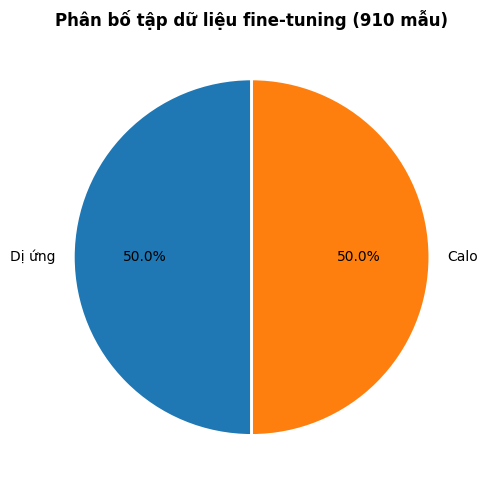

Đã lưu biểu đồ phân bố dataset: /content/drive/MyDrive/VietFood-Project/reports/llm_eval/llm_dataset_distribution.png


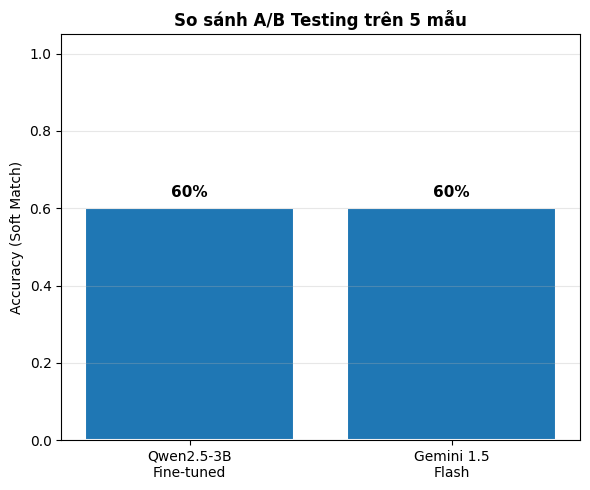

Đã lưu biểu đồ A/B Testing: /content/drive/MyDrive/VietFood-Project/reports/llm_eval/llm_ab_testing_overall.png


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# ==============================
# 1. DATASET DISTRIBUTION
# ==============================
type_counts_plot = {}

for r in records:
    inst = r["instruction"].lower()
    if "dị ứng" in inst:
        k = "Dị ứng"
    elif "calo" in inst or "kcal" in inst:
        k = "Calo"
    else:
        k = "Khác"

    type_counts_plot[k] = type_counts_plot.get(k, 0) + 1

fig1, ax1 = plt.subplots(figsize=(6, 5))

ax1.pie(
    type_counts_plot.values(),
    labels=type_counts_plot.keys(),
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

ax1.set_title(f"Phân bố tập dữ liệu fine-tuning ({len(records)} mẫu)",
              fontweight="bold")

plt.tight_layout()

fig1_path = os.path.join(REPORT_DIR, "llm_dataset_distribution.png")
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ phân bố dataset: {fig1_path}")


# ==============================
# 2. A/B TESTING OVERALL
# ==============================
ft_acc = df_ab["finetune_ok"].mean()
gem_acc = df_ab["gemini_ok"].mean()

models = ["Qwen2.5-3B\nFine-tuned", "Gemini 1.5\nFlash"]
scores = [ft_acc, gem_acc]

fig2, ax2 = plt.subplots(figsize=(6, 5))

bars = ax2.bar(
    models,
    scores,
    edgecolor="white",
    linewidth=1.5
)

ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Accuracy (Soft Match)")
ax2.set_title(f"So sánh A/B Testing trên {len(df_ab)} mẫu",
              fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

for bar, score in zip(bars, scores):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.0%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

fig2_path = os.path.join(REPORT_DIR, "llm_ab_testing_overall.png")
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ A/B Testing: {fig2_path}")

---
## Cell 16 - Lưu báo cáo đầy đủ lên Drive

In [ ]:
import pandas as pd

# DataFrame tổng hợp toàn bộ eval
df_full = pd.DataFrame(eval_samples)
df_full["finetune_partial_match"] = df_full.apply(
    lambda row: row["ground_truth"].lower()[:30] in row["answer"].lower(), axis=1
)
df_full["type"] = df_full["question"].apply(
    lambda q: "allergy" if "dị ứng" in q else "calorie"
)

# Tóm tắt metrics để in
overall_acc = df_full["finetune_partial_match"].mean()
print("=" * 55)
print("BÁO CÁO TỔNG KẾT — Notebook 05: LLM Fine-Tuning")
print("=" * 55)
print(f"\n  Dataset          : {len(records)} mẫu")
print(f"  Train / Test     : {len(train_raw)} / {len(test_raw)}")
print(f"  Model            : Qwen2.5-3B + LoRA (r=16)")
print(f"\n  ── RAGAS Scores ──")
for k, v in ragas_scores.items():
    print(f"    {k:<22}: {v:.4f}")
print(f"\n  ── A/B Testing (Partial Match, n={AB_SAMPLES}) ──")
print(f"    Fine-tuned Qwen2.5-3B : {ft_acc*100:.1f}%")
print(f"    Gemini 3.5 Flash      : {gem_acc*100:.1f}%")
print(f"\n  ── Overall accuracy (test set, partial match) ──")
print(f"    Fine-tuned model      : {overall_acc*100:.1f}%")
print("=" * 55)

# Lưu các file
# 1. CSV chi tiết eval
eval_csv = os.path.join(REPORT_DIR, "eval_results.csv")
df_full.drop(columns=["contexts"]).to_csv(eval_csv, index=False, encoding="utf-8-sig")

# 2. CSV A/B testing
ab_csv = os.path.join(REPORT_DIR, "ab_testing_results.csv")
df_ab.to_csv(ab_csv, index=False, encoding="utf-8-sig")

# 3. JSON tóm tắt metrics
summary = {
    "model": "Qwen2.5-3B-LoRA-r16",
    "dataset_size": len(records),
    "train_size": len(train_raw),
    "test_size": len(test_raw),
    "ragas": ragas_scores,
    "ab_testing": {
        "n_samples": AB_SAMPLES,
        "finetune_acc": float(ft_acc),
        "gemini_acc": float(gem_acc),
    },
    "overall_test_acc": float(overall_acc),
}
summary_json = os.path.join(REPORT_DIR, "eval_summary.json")
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"\nĐã lưu báo cáo:")
print(f"   {eval_csv}")
print(f"   {ab_csv}")
print(f"   {summary_json}")
print(f"   {fig_path}")